# Mushroom Edibility Prediction Using Decision Tree Classifier

### Intorducition

Mushroom classification is important for food safety, as consuming poisonous mushrooms can be harmful. This project uses the Mushroom Classification dataset to predict whether a mushroom is edible or poisonous based on its physical characteristics, such as cap shape, color, and odor. A Decision Tree classifier is applied due to its ability to handle categorical data and provide clear, interpretable results. The model learns patterns from the dataset and makes predictions by splitting data into decision rules. This study demonstrates how machine learning can be used to solve real-world classification problems accurately and transparently.

### Chosen Techniques
This project uses Python as the main programming language due to its powerful libraries for data analysis and machine learning. A Decision Tree classifier is applied to model and predict mushroom edibility based on dataset features. Since the dataset contains categorical variables, a Column Transformer combined with a One-Hot Encoder is used to convert categories into numerical format suitable for the model. To improve performance, GridSearchCV is implemented to find the optimal hyperparameters. Finally, a classification report is used to evaluate the model, providing metrics such as accuracy, precision, recall, and F1-score.

### Dataset
The Mushroom Classification dataset contains records of mushroom samples, each described by a set of categorical features. The dataset includes 8,000+ instances with 22 attributes such as cap shape, cap color, odor, gill size, and habitat. Each feature represents a physical characteristic of a mushroom and is encoded as a categorical variable. The target variable indicates whether a mushroom is edible (e) or poisonous (p). There are no numerical features, making preprocessing essential for machine learning models. The dataset is well-balanced and commonly used for classification tasks, providing a reliable basis for evaluating model performance.

### Input Encoding
The Mushroom dataset consists entirely of categorical features (e.g., cap shape, odor, color), which cannot be directly processed by most machine learning models. Therefore, input encoding is required to convert these categories into a numerical format.
One-Hot Encoding is used to transform each categorical value into a binary vector. For each feature, new columns are created representing possible categories, where 1 indicates presence and 0 indicates absence.
This method prevents the model from assuming any ordinal relationship between categories and allows the Decision Tree to split data effectively based on feature presence, improving accuracy and interpretability.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn import tree

In [2]:
# Load dataset
df = pd.read_csv("mushrooms.csv")
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [4]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [5]:
# Separating features
X = df.iloc[:, 1:] # keep all attributes except target
y = df.iloc[:, 0] # target

X,y

(     cap-shape cap-surface cap-color bruises odor gill-attachment  \
 0            x           s         n       t    p               f   
 1            x           s         y       t    a               f   
 2            b           s         w       t    l               f   
 3            x           y         w       t    p               f   
 4            x           s         g       f    n               f   
 ...        ...         ...       ...     ...  ...             ...   
 8119         k           s         n       f    n               a   
 8120         x           s         n       f    n               a   
 8121         f           s         n       f    n               a   
 8122         k           y         n       f    y               f   
 8123         x           s         n       f    n               a   
 
      gill-spacing gill-size gill-color stalk-shape  ...  \
 0               c         n          k           e  ...   
 1               c         b          

In [6]:
# Select categorical columns
categorical_cols = X.columns.tolist()

In [7]:
# Convert categorical values into numeric format
encoder_step = ColumnTransformer(
                    transformers = [
                            ("encoder", OneHotEncoder(handle_unknown = "ignore"),
                             categorical_cols)], remainder = "passthrough")

In [8]:
# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [9]:
# Create pipeline for a single flow
model_flow = Pipeline([("prepare_data", encoder_step),("tree_model", DecisionTreeClassifier())])

In [10]:
# Set GridSearchCV parameters
parameter = {
                "tree_model__criterion": ["gini", "entropy", "log_loss"],
                "tree_model__splitter": ["best", "random"],
                "tree_model__max_depth": [1, 2, 3, 4, 5],
                "tree_model__max_features": ["sqrt", "log2", None]
}

cv_search = GridSearchCV(model_flow, param_grid = parameter, cv = 5, scoring = "accuracy")
cv_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'tree_model__criterion': ['gini', 'entropy', ...], 'tree_model__max_depth': [1, 2, ...], 'tree_model__max_features': ['sqrt', 'log2', ...], 'tree_model__splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the 

In [11]:
# Display best parameters
print("Best Parameters:")
cv_search.best_params_

Best Parameters:


{'tree_model__criterion': 'entropy',
 'tree_model__max_depth': 5,
 'tree_model__max_features': None,
 'tree_model__splitter': 'best'}

In [12]:
# Predict test data
y_pred = cv_search.predict(X_test)
y_pred

array(['e', 'p', 'p', ..., 'p', 'e', 'e'], shape=(2438,), dtype=object)

In [16]:
# Generate Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1257
           p       1.00      1.00      1.00      1181

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



In [21]:
# Compare values
data_p=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})  
data_p

,Actual,Predicted
1971,e,e
6654,p,p
5606,p,p
3332,e,e
6988,p,p
...,...,...
462,e,e
1956,e,e
3781,p,p
799,e,e


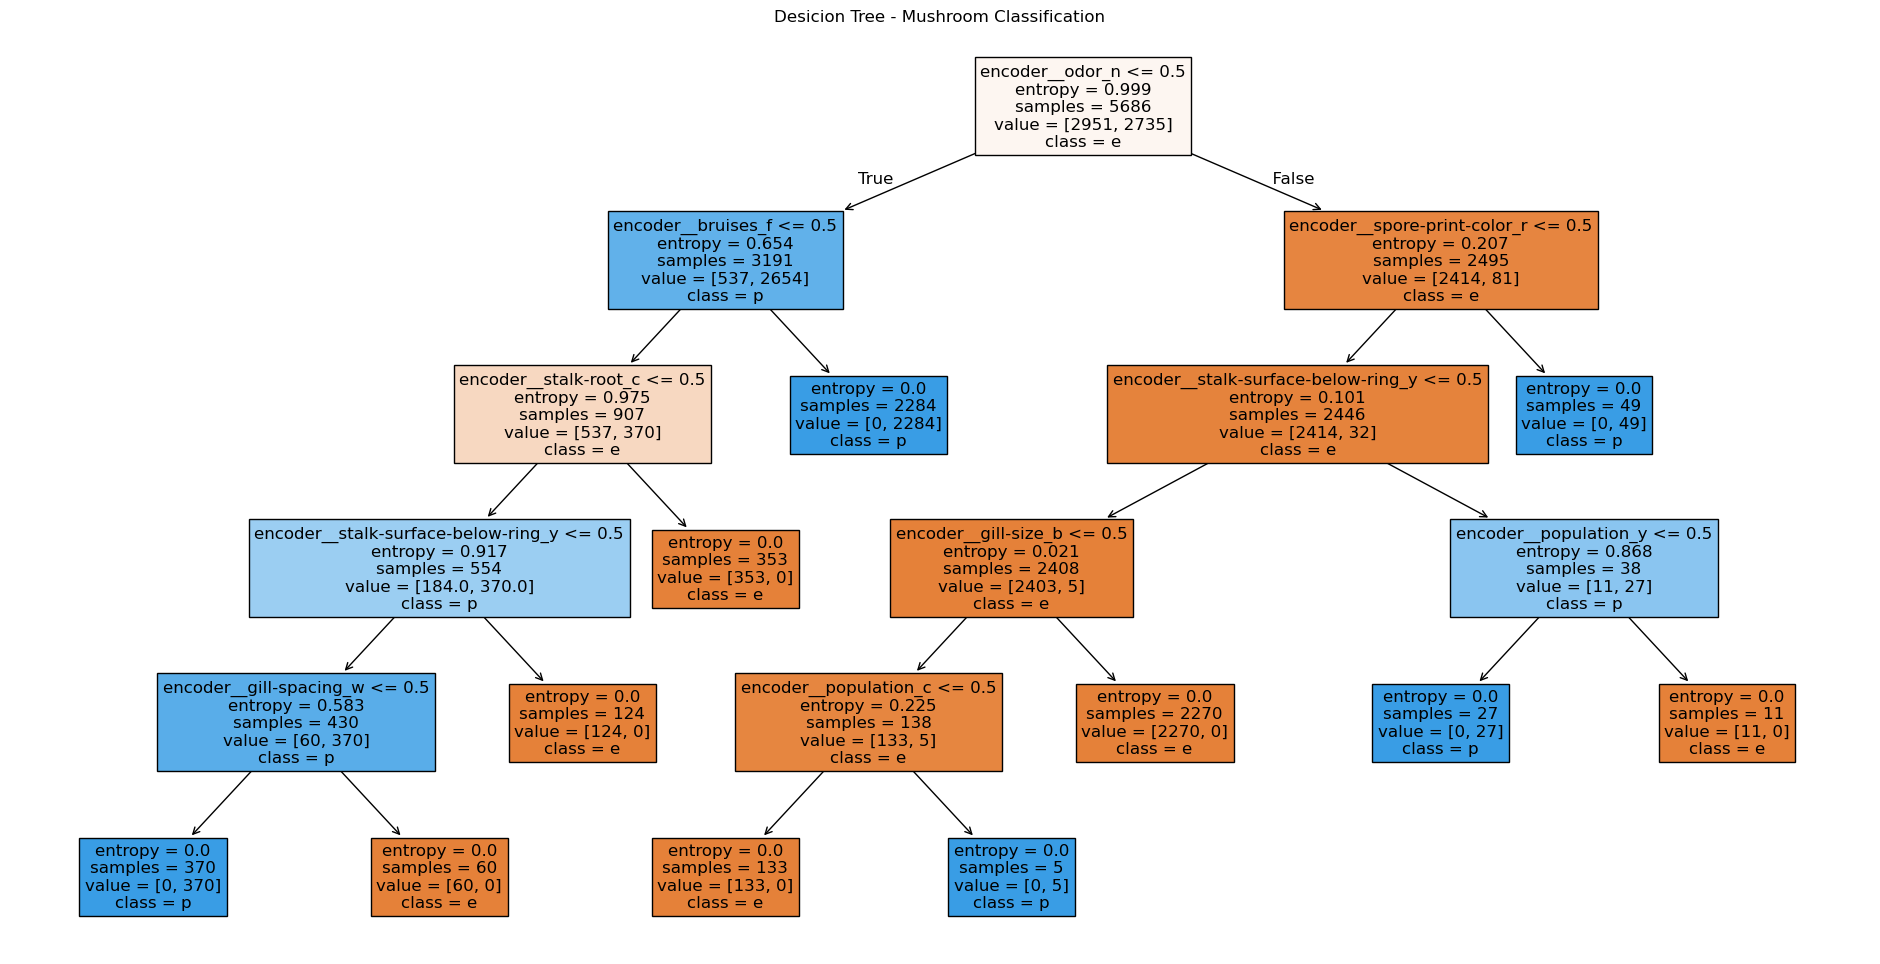

In [36]:
# Plot the decision tree
best_tree = cv_search.best_estimator_.named_steps["tree_model"]
feature_labels = cv_search.best_estimator_.named_steps["prepare_data"].get_feature_names_out()

plt.figure(figsize=(24,12))
tree.plot_tree(best_tree, feature_names = feature_labels, class_names = best_tree.classes_, filled = True, fontsize = 12)
plt.title("Desicion Tree - Mushroom Classification")
plt.show()

### Summary
The decision tree model succesfully classified mushrooms with very high accuracy on the test data. The results show that the feauters in the dataset are highly predictive, allowing the model to clearly distinguish between edible and poisonous mushrooms.